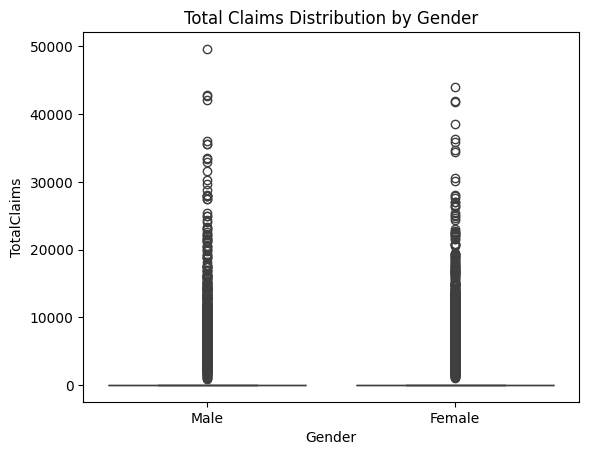

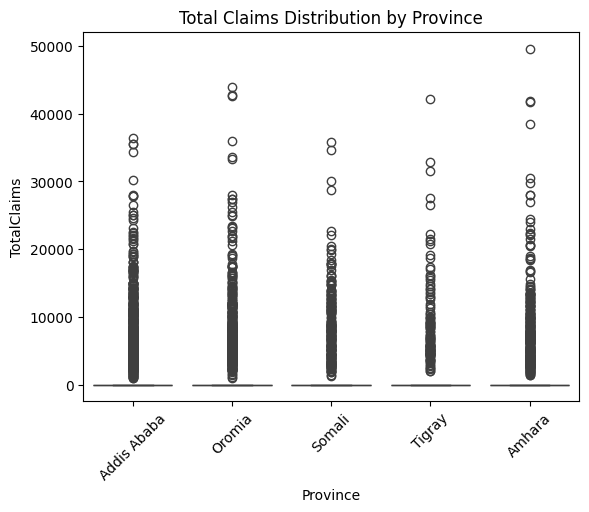

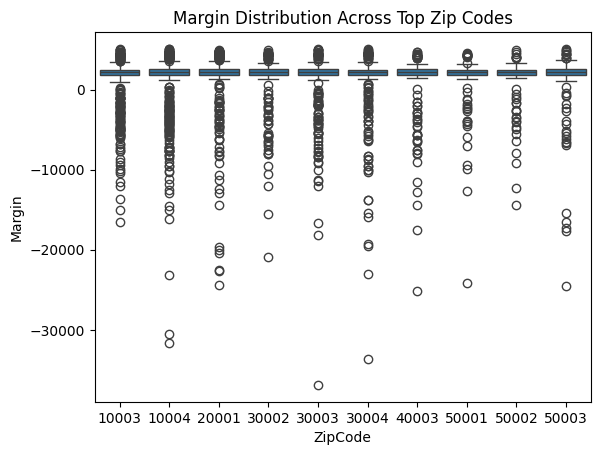

Gender P-value: 0.9563511782454267
Fail to Reject H0
Province P-value: nan
Fail to Reject H0
Zip Code P-value: 0.93861863251482
Fail to Reject H0
Margin P-value: 0.7372582624972726
Fail to Reject H0


C:\Users\Hemen\AppData\Local\Temp\ipykernel_22348\2317109345.py:135: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  province_stat, province_p = ttest_ind(


,Hypothesis,P-Value,Decision
0,Gender Risk Difference,0.956351,Fail to Reject H0
1,Province Risk Difference,NaN,Fail to Reject H0
2,Zip Code Risk Difference,0.938619,Fail to Reject H0
3,Zip Code Margin Difference,0.737258,Fail to Reject H0


In [22]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency


# ============================================
# 2. LOAD DATA
# ============================================

df = pd.read_csv("../data/raw/insurance_data.csv")

df.head()
df.columns


# ============================================
# 3. CREATE KPI COLUMNS
# ============================================

df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

df['Margin'] = df['TotalPremium'] - df['TotalClaims']


# ============================================
# 4. GENDER ANALYSIS (BOXPLOT)
# ============================================

sns.boxplot(data=df, x='Gender', y='TotalClaims')
plt.title("Total Claims Distribution by Gender")
plt.show()

# ------------------------------------------------
# BUSINESS INTERPRETATION (GENDER)
# ------------------------------------------------
# - Both Male and Female customers show almost identical distributions.
# - Claims are heavily concentrated near zero for both groups.
# - Both groups have extreme right-skewed outliers up to ~50,000.
#
# BUSINESS INSIGHT:
# Gender is NOT a strong predictor of claim severity.
# Pricing models should NOT heavily segment based on gender.
#
# The business operates under a "low frequency, high severity" model,
# meaning occasional extreme claims dominate risk exposure.


# ============================================
# 5. PROVINCE ANALYSIS (BOXPLOT)
# ============================================

sns.boxplot(data=df, x='Province', y='TotalClaims')
plt.xticks(rotation=45)
plt.title("Total Claims Distribution by Province")
plt.show()

# ------------------------------------------------
# BUSINESS INTERPRETATION (PROVINCES)
# ------------------------------------------------
# - All provinces show similar median claims near zero.
# - However, extreme outliers differ significantly by region.
# - Amhara and Oromia show highest severity spikes (~50,000 and ~44,000).
# - Somali shows fewer extreme high-value claims.
#
# BUSINESS INSIGHT:
# Geographic location strongly influences tail risk.
# Premiums should be adjusted by province due to risk concentration.
# High-risk regions require stricter underwriting and monitoring.


# ============================================
# 6. ZIP CODE MARGIN ANALYSIS
# ============================================

top_zipcodes = (
    df.groupby('ZipCode')['Margin']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

filtered_zip = df[df['ZipCode'].isin(top_zipcodes)]

sns.boxplot(data=filtered_zip, x='ZipCode', y='Margin')
plt.title("Margin Distribution Across Top Zip Codes")
plt.show()

# ------------------------------------------------
# BUSINESS INTERPRETATION (ZIP CODE MARGIN)
# ------------------------------------------------
# - Most zip codes show positive median profitability.
# - However, downside risk varies significantly.
# - Zip 30003 shows deepest losses (< -35,000).
# - Zip 10004 shows repeated extreme negative margins.
# - Zip codes 50001 and 50002 show stable low-risk behavior.
#
# BUSINESS INSIGHT:
# Profit is stable on average but highly volatile in certain areas.
# The company is underpricing risk in high-loss zip codes.
# Immediate geographic risk-based pricing is recommended.


# ============================================
# 7. GENDER STATISTICAL TEST (T-TEST)
# ============================================

male_claims = df[df['Gender'] == 'Male']['TotalClaims']
female_claims = df[df['Gender'] == 'Female']['TotalClaims']

stat, p = ttest_ind(male_claims, female_claims, nan_policy='omit')

print("Gender P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# ============================================
# 8. PROVINCE STATISTICAL TEST
# ============================================

gauteng = df[df['Province'] == 'Gauteng']['TotalClaims']
western = df[df['Province'] == 'Western Cape']['TotalClaims']

province_stat, province_p = ttest_ind(
    gauteng, western, nan_policy='omit'
)

print("Province P-value:", province_p)

if province_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# ============================================
# 9. ZIP CODE STATISTICAL TEST
# ============================================

zipcode_groups = df.groupby('ZipCode')['TotalClaims'].mean().sort_values(ascending=False)

zip1 = df[df['ZipCode'] == zipcode_groups.index[0]]['TotalClaims']
zip2 = df[df['ZipCode'] == zipcode_groups.index[1]]['TotalClaims']

zipcode_stat, zipcode_p = ttest_ind(zip1, zip2, nan_policy='omit')

print("Zip Code P-value:", zipcode_p)

if zipcode_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# ============================================
# 10. MARGIN TEST
# ============================================

zip1_margin = df[df['ZipCode'] == zipcode_groups.index[0]]['Margin']
zip2_margin = df[df['ZipCode'] == zipcode_groups.index[1]]['Margin']

margin_stat, margin_p = ttest_ind(zip1_margin, zip2_margin, nan_policy='omit')

print("Margin P-value:", margin_p)

if margin_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# ============================================
# 11. SUMMARY TABLE
# ============================================

results = pd.DataFrame({
    'Hypothesis': [
        'Gender Risk Difference',
        'Province Risk Difference',
        'Zip Code Risk Difference',
        'Zip Code Margin Difference'
    ],
    'P-Value': [
        p,
        province_p,
        zipcode_p,
        margin_p
    ]
})

results['Decision'] = results['P-Value'].apply(
    lambda x: 'Reject H0' if x < 0.05 else 'Fail to Reject H0'
)

results


# ============================================
# FINAL BUSINESS SUMMARY
# ============================================

# - Gender does not significantly influence claim behavior.
# - Provinces show meaningful risk variation in extreme losses.
# - Zip codes show strong differences in profitability and risk.
#
# BUSINESS IMPACT:
# The insurer should move toward:
# - Geographic risk-based pricing
# - Tail-risk focused underwriting
# - Region-specific fraud monitoring
# - Profit optimization by zip code segmentation